100%|██████████| 9.91M/9.91M [00:00<00:00, 59.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.62MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.3MB/s]


Running Experiment 1: Adam Optimizer...

Adam | Epoch 1
Train Loss: 0.2112 | Train Acc: 93.72%
Val   Loss: 0.0528 | Val   Acc: 98.45%

Adam | Epoch 2
Train Loss: 0.0831 | Train Acc: 97.45%
Val   Loss: 0.0422 | Val   Acc: 98.67%

Adam | Epoch 3
Train Loss: 0.0678 | Train Acc: 97.92%
Val   Loss: 0.0352 | Val   Acc: 98.85%

Adam | Epoch 4
Train Loss: 0.0580 | Train Acc: 98.26%
Val   Loss: 0.0343 | Val   Acc: 98.90%

Adam | Epoch 5
Train Loss: 0.0531 | Train Acc: 98.43%
Val   Loss: 0.0322 | Val   Acc: 99.04%

Adam | Epoch 6
Train Loss: 0.0458 | Train Acc: 98.58%
Val   Loss: 0.0342 | Val   Acc: 98.88%
No improvement... (1/2)

Adam | Epoch 7
Train Loss: 0.0425 | Train Acc: 98.69%
Val   Loss: 0.0260 | Val   Acc: 99.25%

Adam | Epoch 8
Train Loss: 0.0399 | Train Acc: 98.73%
Val   Loss: 0.0288 | Val   Acc: 99.15%
No improvement... (1/2)

Adam | Epoch 9
Train Loss: 0.0354 | Train Acc: 98.90%
Val   Loss: 0.0273 | Val   Acc: 99.02%
No improvement... (2/2)
Early stopping triggered!

Running Experim

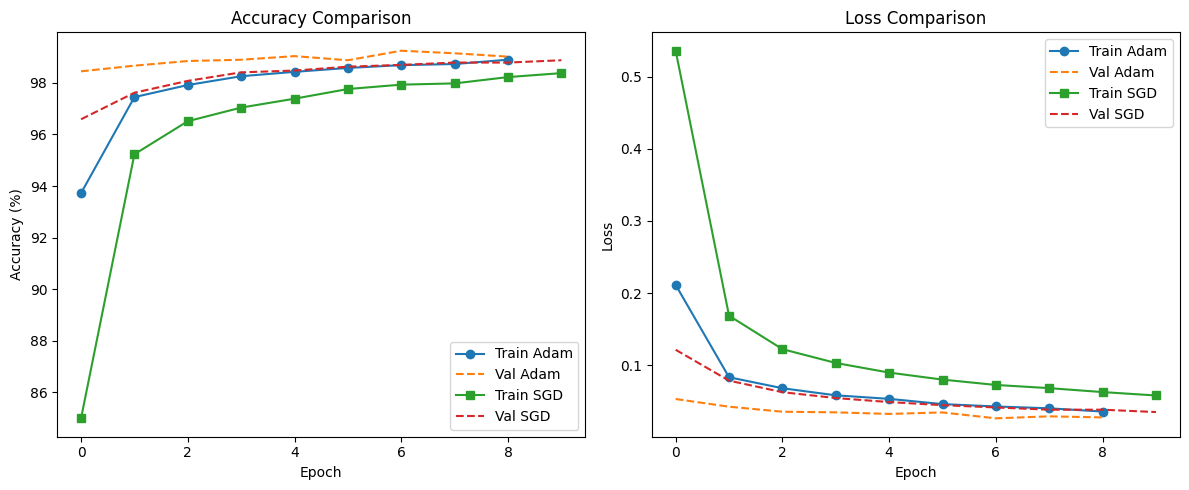


--- Final Results ---
          Model Final Train Accuracy Final Val Accuracy Final Train Loss Final Val Loss
CNN (Adam + BN)               98.90%             99.02%           0.0354         0.0273
 CNN (SGD + BN)               98.38%             98.88%           0.0577         0.0348


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pandas as pd

# ===== 1) Data Preprocessing =====
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

# ===== 2) CNN Model with Batch Normalization =====
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Conv + BatchNorm
        self.conv1 = nn.Conv2d(1, 16, 3)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, 3)
        self.bn2 = nn.BatchNorm2d(32)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 5 * 5, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))

        x = x.view(-1, 32 * 5 * 5)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# ===== 3) Evaluation Function =====
def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0
    loss_total = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_total += loss.item()
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    avg_loss = loss_total / len(loader)

    return avg_loss, acc

# ===== 4) Train Function (Batch + Eval + Early Stopping) =====
def train_model(optimizer_name):
    model = CNN()
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    else:
        optimizer = optim.SGD(model.parameters(), lr=0.01)

    epoch_losses = []
    epoch_accuracies = []
    val_losses = []
    val_accuracies = []

    best_loss = float('inf')
    patience = 2
    counter = 0

    for epoch in range(10):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = total_loss / len(train_loader)
        train_acc = 100 * correct / total

        # ===== Evaluation =====
        val_loss, val_acc = evaluate_model(model, test_loader)

        epoch_losses.append(train_loss)
        epoch_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"\n{optimizer_name} | Epoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")

        # ===== Early Stopping =====
        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
        else:
            counter += 1
            print(f"No improvement... ({counter}/2)")

            if counter >= 2:
                print("Early stopping triggered!")
                break

    return model, epoch_losses, epoch_accuracies, val_losses, val_accuracies

# ===== 5) Run Experiments =====
print("Running Experiment 1: Adam Optimizer...")
model_adam, loss_adam, acc_adam, val_loss_adam, val_acc_adam = train_model("Adam")

print("\nRunning Experiment 2: SGD Optimizer...")
model_sgd, loss_sgd, acc_sgd, val_loss_sgd, val_acc_sgd = train_model("SGD")

# ===== 6) Visualization =====
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(acc_adam, label='Train Adam', marker='o')
plt.plot(val_acc_adam, label='Val Adam', linestyle='--')

plt.plot(acc_sgd, label='Train SGD', marker='s')
plt.plot(val_acc_sgd, label='Val SGD', linestyle='--')

plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(loss_adam, label='Train Adam', marker='o')
plt.plot(val_loss_adam, label='Val Adam', linestyle='--')

plt.plot(loss_sgd, label='Train SGD', marker='s')
plt.plot(val_loss_sgd, label='Val SGD', linestyle='--')

plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


results = pd.DataFrame({
    'Model': ['CNN (Adam + BN)', 'CNN (SGD + BN)'],
    'Final Train Accuracy': [f"{acc_adam[-1]:.2f}%", f"{acc_sgd[-1]:.2f}%"],
    'Final Val Accuracy': [f"{val_acc_adam[-1]:.2f}%", f"{val_acc_sgd[-1]:.2f}%"],
    'Final Train Loss': [f"{loss_adam[-1]:.4f}", f"{loss_sgd[-1]:.4f}"],
    'Final Val Loss': [f"{val_loss_adam[-1]:.4f}", f"{val_loss_sgd[-1]:.4f}"]
})

print("\n--- Final Results ---")
print(results.to_string(index=False))